# 01 - Overview de seguridad por repositorio

## Introducción
Este notebook presenta una vista ejecutiva del pipeline **Miner → Analyzer → Visualizer**.
Su objetivo es explorar los datos crudos del Miner, verificar trazabilidad con el consolidado `analysis.json`,
y presentar métricas por repositorio.

## Pregunta que responde
**¿Tenemos evidencia trazable y consistente desde los artefactos raw hasta el dataset consolidado `analysis.json`?**

### Cómo interpretar esta sección
- **FASE 1**: Exploración directa de datos raw del Miner (SBOM, Grype, CodeQL normalized, CI/CD).
- **FASE 2**: Carga y validación del consolidado `analysis.json`.
- **Validación cruzada**: Comparación de conteos entre raw y consolidado.

### Por qué importa en ciberseguridad
Sin trazabilidad de datos, cualquier priorización de riesgo puede ser discutible. Este overview asegura base empírica mínima antes de concluir sobre exposición real.


## Origen de datos del Miner y significado del consolidado

- **SBOM (Syft)**: inventario de componentes desde `data/results/sboms/*_sbom.json`.
- **Vulnerabilidades (Grype)**: hallazgos desde `data/results/vulns/*_vuln.json`.
- **SAST (CodeQL)**: issues normalizados desde `data/reports/*_codeql_normalized.json`.
- **CI/CD findings (Bonus)**: señales de workflows/automatización insegura en `data/reports/*_cicd.json`. **Análisis secundario**: estos hallazgos son operativos y de menor prioridad que vulnerabilidades de dependencias o código.

`analysis.json` funciona como **dataset consolidado estable**: integra resultados por repositorio y habilita comparaciones transversales sin depender de leer múltiples formatos en cada análisis.

### Significado de `metadata.validation`
`metadata.validation` resume calidad de ingestión:
- `warnings`: situaciones no bloqueantes (por ejemplo, cobertura parcial).
- `invalid_files`: artefactos que no cumplieron formato esperado.

## Glosario breve
- **SBOM**: lista estructurada de componentes de software.
- **Syft**: herramienta para generar SBOM.
- **Grype**: escáner de vulnerabilidades sobre componentes detectados.
- **CodeQL**: análisis estático de código para detectar patrones de riesgo.
- **CI/CD finding (Bonus)**: hallazgo operativo en pipelines. Análisis complementario de menor prioridad.
- **CWE**: clasificación estandarizada de tipos de debilidad.
- **CVSS**: Common Vulnerability Scoring System (0-10, severidad técnica).
- **EPSS**: Exploit Prediction Scoring System (probabilidad de explotación real).
- **risk_score**: Riesgo Acumulado Topado — combina Grype y CodeQL con pesos (Critical/Error=4, High=3, Medium/Warning=2, Low/Note=1), dividido por 10. Excluye CI/CD de la ecuación principal.


## FASE 1 — Exploración de datos raw del Miner

Se leen directamente los archivos generados por el Miner para realizar análisis exploratorio sobre los datos crudos.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'results').exists():
            return candidate
    return Path.cwd()


root = find_project_root()
sbom_dir = root / 'data' / 'results' / 'sboms'
vuln_dir = root / 'data' / 'results' / 'vulns'
reports_dir = root / 'data' / 'reports'
analysis_path = root / 'data' / 'results' / 'analysis.json'

# ── Carga RAW: SBOM ──
sbom_rows = []
for p in sorted(sbom_dir.glob('*_sbom.json')):
    data = json.loads(p.read_text(encoding='utf-8'))
    repo = p.name.replace('_sbom.json', '')
    for art in data.get('artifacts', []):
        sbom_rows.append({
            'repo': repo,
            'name': art.get('name', ''),
            'version': art.get('version', 'UNKNOWN'),
            'type': art.get('type', 'unknown'),
            'language': art.get('language', '') or 'unknown',
        })
df_sbom_raw = pd.DataFrame(sbom_rows)
if df_sbom_raw.empty:
    df_sbom_raw = pd.DataFrame(columns=['repo','name','version','type','language'])

# ── Carga RAW: Grype ──
grype_rows = []
for p in sorted(vuln_dir.glob('*_vuln.json')):
    data = json.loads(p.read_text(encoding='utf-8'))
    repo = p.name.replace('_vuln.json', '')
    for match in data.get('matches', []):
        vuln = match.get('vulnerability', {})
        artifact = match.get('artifact', {})
        cvss_list = vuln.get('cvss', [])
        cvss_score = None
        if isinstance(cvss_list, list) and cvss_list:
            first = cvss_list[0]
            if isinstance(first, dict):
                metrics = first.get('metrics', {})
                if isinstance(metrics, dict):
                    cvss_score = metrics.get('baseScore')
        epss_list = vuln.get('epss', [])
        epss = None
        if isinstance(epss_list, list) and epss_list:
            first = epss_list[0]
            if isinstance(first, dict):
                epss = first.get('epss')
        fix = vuln.get('fix', {})
        grype_rows.append({
            'repo': repo,
            'id': vuln.get('id', ''),
            'severity': vuln.get('severity', 'Unknown'),
            'description': vuln.get('description', ''),
            'cvss_score': cvss_score,
            'epss': epss,
            'risk': vuln.get('risk'),
            'artifact': artifact.get('name', ''),
            'artifact_version': artifact.get('version', ''),
            'artifact_type': artifact.get('type', 'unknown'),
            'fix_state': fix.get('state', 'unknown'),
            'fix_available': fix.get('state', '').lower() == 'fixed' or bool(fix.get('versions')),
            'fix_version': fix.get('versions', [None])[0] if fix.get('versions') else None,
        })
df_grype_raw = pd.DataFrame(grype_rows)
if df_grype_raw.empty:
    df_grype_raw = pd.DataFrame(columns=['repo','id','severity','description','cvss_score','epss','risk','artifact','artifact_version','artifact_type','fix_state','fix_available','fix_version'])

# ── Carga RAW: CodeQL normalized ──
codeql_rows = []
for p in sorted(reports_dir.glob('*_codeql_normalized.json')):
    data = json.loads(p.read_text(encoding='utf-8'))
    repo = p.name.replace('_codeql_normalized.json', '')
    for issue in data.get('issues', []):
        codeql_rows.append({
            'repo': repo,
            'rule_id': issue.get('rule_id', ''),
            'rule_name': issue.get('rule_name', ''),
            'level': issue.get('level', 'unknown'),
            'message': issue.get('message', ''),
            'file': issue.get('file', ''),
            'line': issue.get('line'),
            'column': issue.get('column'),
        })
df_codeql_raw = pd.DataFrame(codeql_rows)
if df_codeql_raw.empty:
    df_codeql_raw = pd.DataFrame(columns=['repo','rule_id','rule_name','level','message','file','line','column'])

# ── Carga RAW: CI/CD ──
cicd_rows = []
for p in sorted(reports_dir.glob('*_cicd.json')):
    data = json.loads(p.read_text(encoding='utf-8'))
    repo = p.name.replace('_cicd.json', '')
    for finding in data.get('findings', []):
        for issue in finding.get('issues', []):
            cicd_rows.append({
                'repo': repo,
                'workflow': finding.get('workflow', ''),
                'issue': issue,
            })
df_cicd_raw = pd.DataFrame(cicd_rows)
if df_cicd_raw.empty:
    df_cicd_raw = pd.DataFrame(columns=['repo','workflow','issue'])

print(f"SBOM raw: {len(df_sbom_raw)} componentes en {df_sbom_raw['repo'].nunique()} repos")
print(f"Grype raw: {len(df_grype_raw)} vulnerabilidades en {df_grype_raw['repo'].nunique()} repos")
print(f"CodeQL raw: {len(df_codeql_raw)} issues en {df_codeql_raw['repo'].nunique()} repos")
print(f"CI/CD raw: {len(df_cicd_raw)} hallazgos en {df_cicd_raw['repo'].nunique()} repos")


SBOM raw: 8245 componentes en 12 repos
Grype raw: 60 vulnerabilidades en 9 repos
CodeQL raw: 47 issues en 5 repos
CI/CD raw: 20 hallazgos en 7 repos


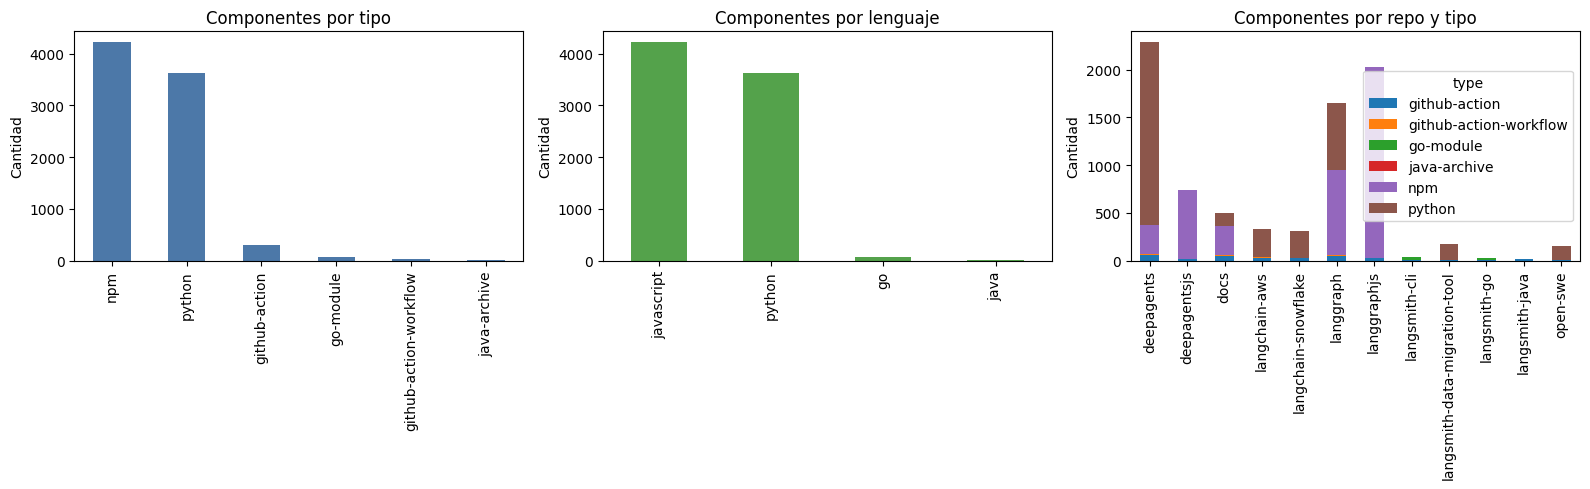

In [2]:
# ── EDA: SBOM por tipo y lenguaje ──
if not df_sbom_raw.empty:
    by_type = df_sbom_raw['type'].value_counts()
    by_lang = df_sbom_raw[df_sbom_raw['language'] != 'unknown']['language'].value_counts()
    by_repo_type = df_sbom_raw.groupby(['repo', 'type']).size().unstack(fill_value=0)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    by_type.plot(kind='bar', ax=axes[0], color='#4C78A8', title='Componentes por tipo')
    by_lang.plot(kind='bar', ax=axes[1], color='#54A24B', title='Componentes por lenguaje')
    by_repo_type.plot(kind='bar', stacked=True, ax=axes[2], title='Componentes por repo y tipo')
    for ax in axes:
        ax.set_xlabel('')
        ax.set_ylabel('Cantidad')
    plt.tight_layout()
    plt.show()
else:
    print('Sin datos SBOM raw.')


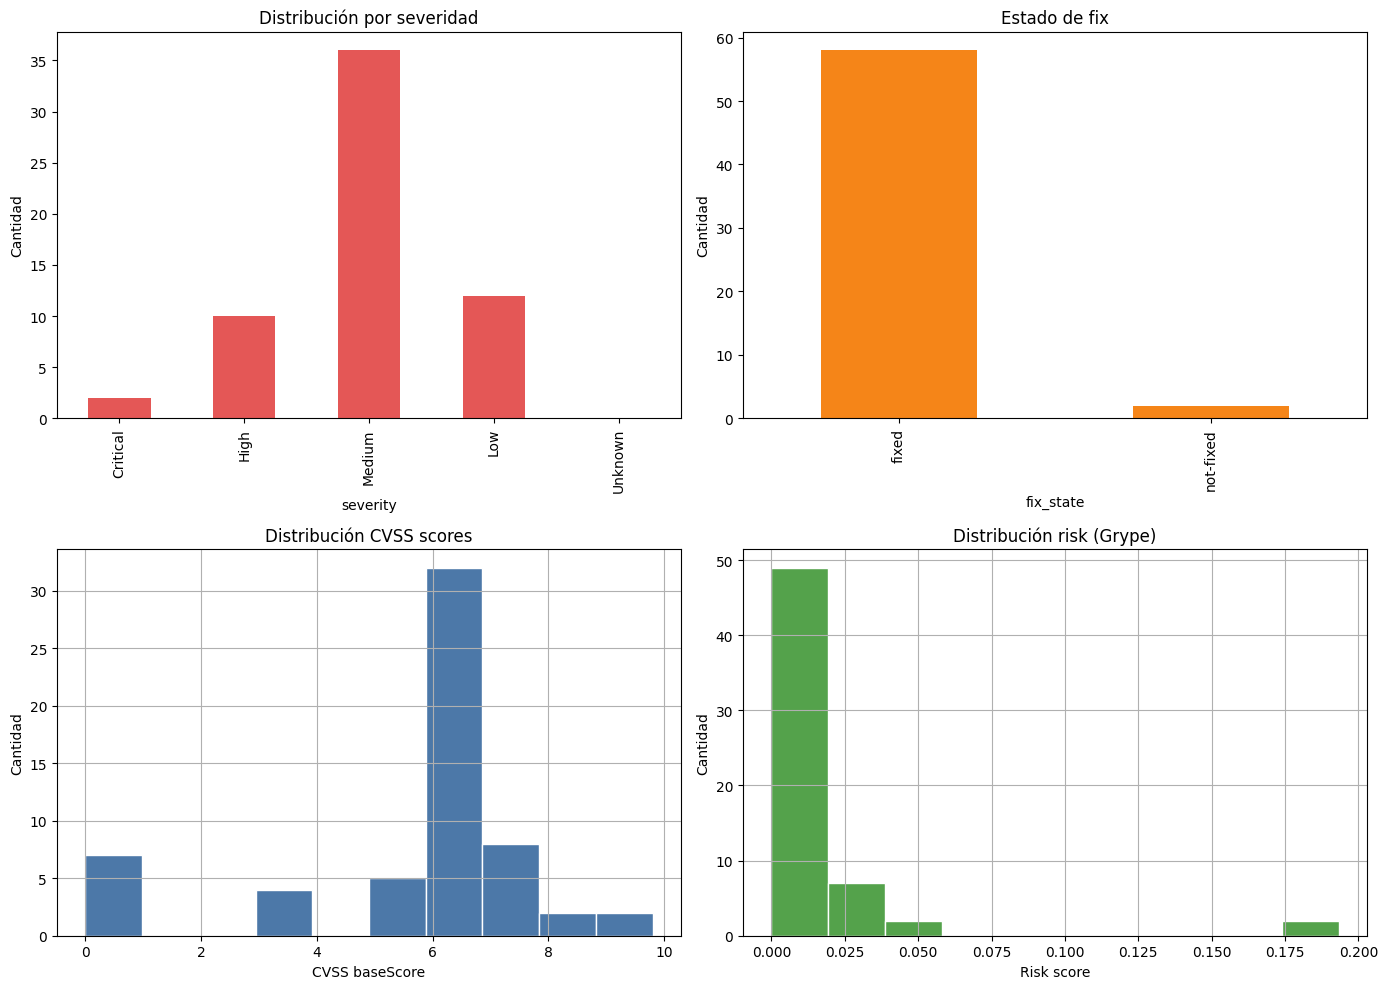


CVSS promedio: 5.66
EPSS promedio: 0.000450
Risk promedio: 0.014852
Fix disponible: 58/60 (96.7%)


In [3]:
# ── EDA: Grype — severidad, CVSS, EPSS, risk, fix states ──
if not df_grype_raw.empty:
    sev_order = ['Critical', 'High', 'Medium', 'Low', 'Unknown']
    sev_counts = df_grype_raw['severity'].value_counts().reindex(sev_order, fill_value=0)
    fix_counts = df_grype_raw['fix_state'].value_counts()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    sev_counts.plot(kind='bar', ax=axes[0, 0], color='#E45756', title='Distribución por severidad')
    fix_counts.plot(kind='bar', ax=axes[0, 1], color='#F58518', title='Estado de fix')

    if df_grype_raw['cvss_score'].notna().any():
        df_grype_raw['cvss_score'].hist(bins=10, ax=axes[1, 0], color='#4C78A8', edgecolor='white')
        axes[1, 0].set_title('Distribución CVSS scores')
        axes[1, 0].set_xlabel('CVSS baseScore')
    else:
        axes[1, 0].text(0.5, 0.5, 'Sin datos CVSS', ha='center', va='center')
        axes[1, 0].set_title('Distribución CVSS scores')

    if df_grype_raw['risk'].notna().any():
        df_grype_raw['risk'].hist(bins=10, ax=axes[1, 1], color='#54A24B', edgecolor='white')
        axes[1, 1].set_title('Distribución risk (Grype)')
        axes[1, 1].set_xlabel('Risk score')
    else:
        axes[1, 1].text(0.5, 0.5, 'Sin datos risk', ha='center', va='center')
        axes[1, 1].set_title('Distribución risk (Grype)')

    for ax in axes.ravel():
        ax.set_ylabel('Cantidad')
    plt.tight_layout()
    plt.show()

    print(f"\nCVSS promedio: {df_grype_raw['cvss_score'].mean():.2f}" if df_grype_raw['cvss_score'].notna().any() else "\nSin datos CVSS.")
    print(f"EPSS promedio: {df_grype_raw['epss'].mean():.6f}" if df_grype_raw['epss'].notna().any() else "Sin datos EPSS.")
    print(f"Risk promedio: {df_grype_raw['risk'].mean():.6f}" if df_grype_raw['risk'].notna().any() else "Sin datos risk.")
    print(f"Fix disponible: {df_grype_raw['fix_available'].sum()}/{len(df_grype_raw)} ({df_grype_raw['fix_available'].mean()*100:.1f}%)")
else:
    print('Sin datos Grype raw.')


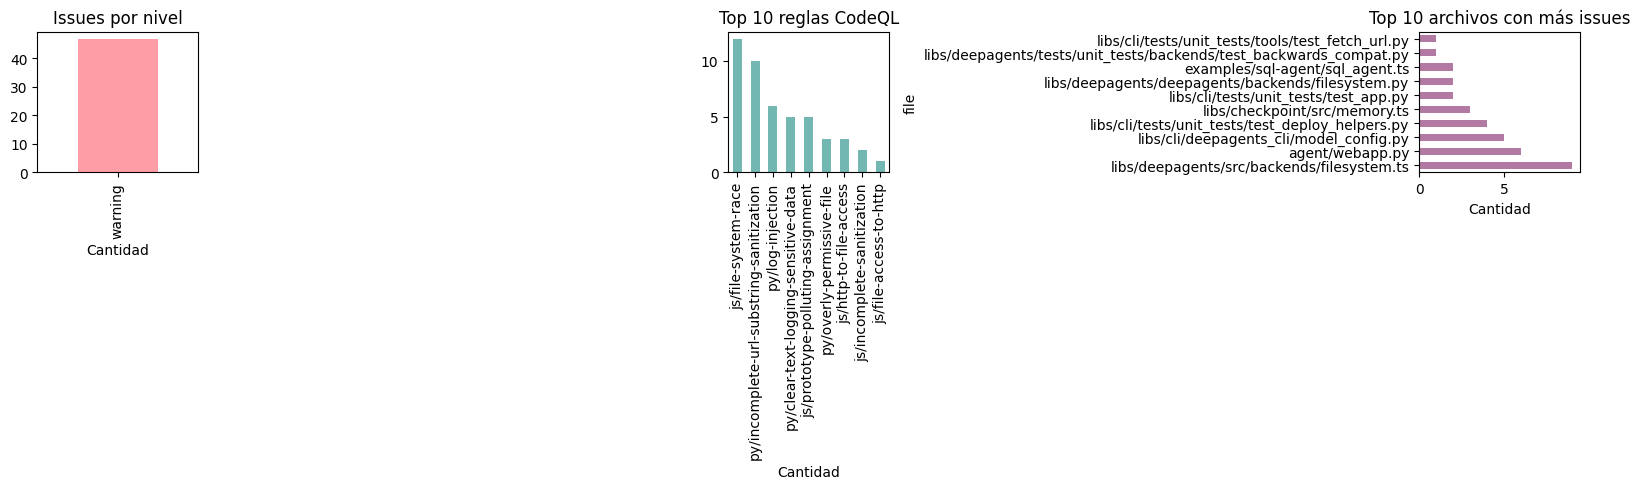

In [4]:
# ── EDA: CodeQL — niveles, top reglas, top archivos ──
if not df_codeql_raw.empty:
    level_counts = df_codeql_raw['level'].value_counts()
    top_rules = df_codeql_raw['rule_id'].value_counts().head(10)
    top_files = df_codeql_raw['file'].value_counts().head(10)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    level_counts.plot(kind='bar', ax=axes[0], color='#FF9DA6', title='Issues por nivel')
    top_rules.plot(kind='bar', ax=axes[1], color='#72B7B2', title='Top 10 reglas CodeQL')
    top_files.plot(kind='barh', ax=axes[2], color='#B279A2', title='Top 10 archivos con más issues')
    for ax in axes:
        ax.set_xlabel('Cantidad')
    plt.tight_layout()
    plt.show()
else:
    print('Sin datos CodeQL raw.')


## Validación cruzada: RAW vs analysis.json

Se compara el conteo de items entre los archivos raw y el consolidado para verificar que no hay pérdida de datos.


In [5]:
if not analysis_path.exists():
    print(f'No se encontró analysis.json en: {analysis_path}')
else:
    analysis = json.loads(analysis_path.read_text(encoding='utf-8'))
    repos = analysis.get('repositories', []) or []
    metadata = analysis.get('metadata', {}) or {}

    cross_rows = []
    for repo in repos:
        name = repo.get('name', 'unknown')
        raw_sbom_count = len(df_sbom_raw[df_sbom_raw['repo'] == name]) if not df_sbom_raw.empty else 0
        raw_vuln_count = len(df_grype_raw[df_grype_raw['repo'] == name]) if not df_grype_raw.empty else 0
        raw_codeql_count = len(df_codeql_raw[df_codeql_raw['repo'] == name]) if not df_codeql_raw.empty else 0
        raw_cicd_count = len(df_cicd_raw[df_cicd_raw['repo'] == name]) if not df_cicd_raw.empty else 0

        cons_sbom = repo.get('sbom', {}).get('total_components', 0)
        cons_vuln = repo.get('vulnerabilities', {}).get('total', 0)
        cons_codeql = repo.get('codeql', {}).get('total_issues', 0)
        cons_cicd = repo.get('cicd', {}).get('total_findings', 0)

        cross_rows.append({
            'repo': name,
            'sbom_raw': raw_sbom_count, 'sbom_cons': cons_sbom, 'sbom_match': raw_sbom_count == cons_sbom,
            'vuln_raw': raw_vuln_count, 'vuln_cons': cons_vuln, 'vuln_match': raw_vuln_count == cons_vuln,
            'codeql_raw': raw_codeql_count, 'codeql_cons': cons_codeql, 'codeql_match': raw_codeql_count == cons_codeql,
            'cicd_raw': raw_cicd_count, 'cicd_cons': cons_cicd, 'cicd_match': raw_cicd_count == cons_cicd,
        })

    df_cross = pd.DataFrame(cross_rows)
    display(df_cross)

    all_match = df_cross[['sbom_match','vuln_match','codeql_match','cicd_match']].all().all()
    print(f"\nValidación cruzada: {'✓ Todos los conteos coinciden' if all_match else '✗ Hay discrepancias'}")


,repo,sbom_raw,sbom_cons,sbom_match,vuln_raw,vuln_cons,vuln_match,codeql_raw,codeql_cons,codeql_match,cicd_raw,cicd_cons,cicd_match
0,deepagents,2286,2286,True,10,10,True,12,12,True,2,2,True
1,deepagentsjs,740,740,True,5,5,True,12,12,True,8,8,True
2,docs,502,502,True,5,5,True,0,0,True,0,0,True
3,langchain-aws,333,333,True,2,2,True,0,0,True,1,1,True
4,langchain-snowflake,306,306,True,7,7,True,0,0,True,0,0,True
5,langgraph,1649,1649,True,18,18,True,6,6,True,1,1,True
6,langgraphjs,2022,2022,True,8,8,True,11,11,True,6,6,True
7,langsmith-cli,41,41,True,0,0,True,0,0,True,1,1,True
8,langsmith-data-migration-tool,170,170,True,3,3,True,0,0,True,1,1,True
9,langsmith-go,31,31,True,0,0,True,0,0,True,0,0,True



Validación cruzada: ✓ Todos los conteos coinciden


## FASE 2 — Dataset consolidado (analysis.json)


In [6]:
if not analysis_path.exists():
    raise FileNotFoundError(f'No se encontró analysis.json en: {analysis_path}')

analysis = json.loads(analysis_path.read_text(encoding='utf-8'))
repos = analysis.get('repositories', []) or []
metadata = analysis.get('metadata', {}) or {}

metadata

{'generated_at': '2026-05-05T02:46:28.797239+00:00',
 'repos_analyzed': 12,
 'data_sources': ['sbom', 'grype', 'codeql', 'cicd'],
 'validation': {'warnings': [], 'invalid_files': []}}

In [7]:
validation = metadata.get('validation', {}) or {}
warnings = validation.get('warnings', []) or []
invalid_files = validation.get('invalid_files', []) or []

print('Resumen de validación:')
print(f"- warnings: {len(warnings)}")
print(f"- invalid_files: {len(invalid_files)}")

if warnings:
    print('\nWarnings:')
    for w in warnings:
        print(f'- {w}')

if invalid_files:
    print('\nArchivos inválidos:')
    for f in invalid_files:
        print(f'- {f}')

if not warnings and not invalid_files:
    print('\nSin advertencias ni archivos inválidos en metadata.validation.')

Resumen de validación:
- warnings: 0
- invalid_files: 0

Sin advertencias ni archivos inválidos en metadata.validation.


In [8]:
rows = []
for repo in repos:
    rows.append({
        'name': repo.get('name', 'unknown'),
        'components': repo.get('sbom', {}).get('total_components', 0),
        'vulnerabilities': repo.get('vulnerabilities', {}).get('total', 0),
        'codeql_issues': repo.get('codeql', {}).get('total_issues', 0),
        'cicd_findings': repo.get('cicd', {}).get('total_findings', 0),
        'risk_score': repo.get('metrics', {}).get('risk_score', 0.0),
        'risk_score_raw': repo.get('metrics', {}).get('risk_score_raw', 0.0),
        'vulnerability_density': repo.get('metrics', {}).get('vulnerability_density', 0.0),
    })

df_repos = pd.DataFrame(rows)
if df_repos.empty:
    df_repos = pd.DataFrame(columns=[
        'name','components','vulnerabilities','codeql_issues','cicd_findings','risk_score','risk_score_raw','vulnerability_density'
    ])

df_repos = df_repos.sort_values('risk_score', ascending=False).reset_index(drop=True)
df_repos_top = df_repos.head(15)
df_repos_top

,name,components,vulnerabilities,codeql_issues,cicd_findings,risk_score,risk_score_raw,vulnerability_density
0,open-swe,151,0,6,0,5.45,2.18,0.000000
1,deepagents,2286,10,12,2,5.28,2.11,0.437445
2,langgraph,1649,18,6,1,4.14,1.66,1.091571
3,langgraphjs,2022,8,11,6,4.06,1.62,0.395648
4,deepagentsjs,740,5,12,8,3.86,1.55,0.675676
5,langchain-snowflake,306,7,0,0,2.71,1.08,2.287582
6,docs,502,5,0,0,2.25,0.90,0.996016
7,langsmith-java,14,2,0,0,2.14,0.86,14.285714
8,langsmith-data-migration-tool,170,3,0,1,1.88,0.75,1.764706
9,langchain-aws,333,2,0,1,0.71,0.29,0.600601


## Gráficos de distribución por repositorio

### Cómo interpretar esta sección
- **components**: tamaño del inventario analizado.
- **vulnerabilities**: volumen de exposición detectada por Grype.
- **codeql_issues**: señales de riesgo en código propio.
- **cicd_findings**: riesgos operativos en automatización.
- **risk_score_raw**: Riesgo acumulado (Grype + CodeQL) sin topar.
- **risk_score**: Versión topada a máximo 10 para comparar repositorios.
- **cicd_findings (Bonus)**: análisis complementario de hallazgos operativos en pipelines.
- **vulnerability_density**: vulnerabilidades por 100 componentes (`total_vulnerabilities / max(total_components,1) * 100`).

### Por qué importa en ciberseguridad
Mirar solo totales puede sesgar decisiones. Estas métricas combinadas permiten distinguir entre repos grandes con riesgo distribuido y repos pequeños con concentración crítica.


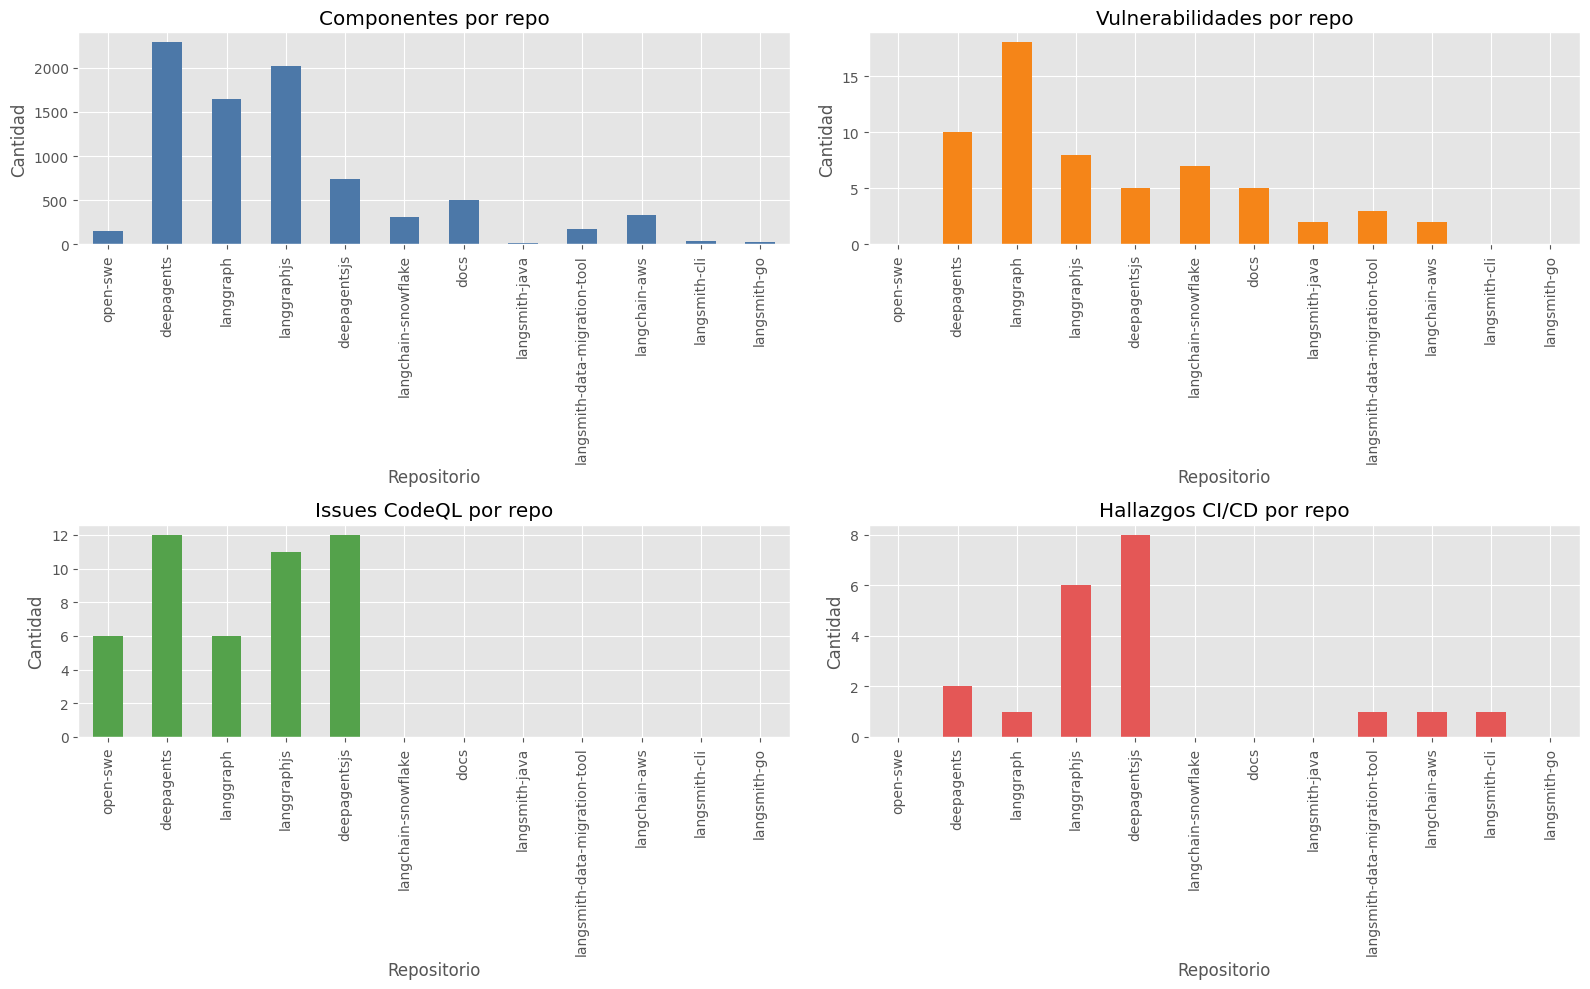

In [9]:
plt.style.use('ggplot')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

if not df_repos.empty:
    top = df_repos.head(15)
    top.plot.bar(x='name', y='components', ax=axes[0, 0], legend=False, color='#4C78A8')
    top.plot.bar(x='name', y='vulnerabilities', ax=axes[0, 1], legend=False, color='#F58518')
    top.plot.bar(x='name', y='codeql_issues', ax=axes[1, 0], legend=False, color='#54A24B')
    top.plot.bar(x='name', y='cicd_findings', ax=axes[1, 1], legend=False, color='#E45756')
else:
    for ax in axes.ravel():
        ax.text(0.5, 0.5, 'Sin datos de repositorio', ha='center', va='center')

axes[0, 0].set_title('Componentes por repo')
axes[0, 1].set_title('Vulnerabilidades por repo')
axes[1, 0].set_title('Issues CodeQL por repo')
axes[1, 1].set_title('Hallazgos CI/CD por repo')

for ax in axes.ravel():
    ax.set_xlabel('Repositorio')
    ax.set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

## Conclusión parcial
Este notebook permite verificar que los datos raw existen, que el dataset consolidado fue generado correctamente,
que existe trazabilidad entre los resultados del Miner y el análisis posterior, y que los conteos entre raw y consolidado coinciden.
